In [26]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('/content/ecommerce_product_dataset (2).csv')
df

,nama_produk,harga,rating,jumlah_terjual,lokasi_penjual,brand,kategori,kondisi,platform
0,ZTE Nubia Z50 (5G) (12GB/256GB) (The Best Of C...,9499000,NaN,0,Kota Administrasi Jakarta Barat,Zte,Hp,Baru,Tokopedia
1,ZTE Nubia Redmagic 8s Pro 16GB/512GB Garansi R...,14999000,NaN,0,Kota Administrasi Jakarta Barat,Zte,Hp,Baru,Tokopedia
2,ZTE Nubia Z50 (5G) (12GB/256GB) (Jaminan Produ...,9499000,NaN,0,Kota Administrasi Jakarta Barat,Zte,Hp,Baru,Tokopedia
3,Digitalisme x Promo Nubia RedMagic 11 Pro 16GB...,17652000,5.0,6,Kota Administrasi Jakarta Pusat,Zte,Hp,Baru,Tokopedia
4,ZTE AXON 30 ULTRA 5G SD888 12GB 256GB 128GB BL...,70652400,NaN,0,Kota Administrasi Jakarta Selatan,Zte,Hp,Baru,Tokopedia
...,...,...,...,...,...,...,...,...,...
35445,"Macbook Pro (14 inch, M4 Max, 36GB)",55499000,4.6,9,Blibli - Apple Authorized Reseller Flagship Store,Apple,Laptop,Baru,Blibli
35446,"MacBook Air (15 inci, M3, 16 GB, 2024)",19499000,5.0,20,Blibli - Apple Authorized Reseller Flagship Store,Apple,Laptop,Baru,Blibli
35447,"Macbook Pro (14 inch, M4, 24GB)",33999000,5.0,10,Blibli - Apple Authorized Reseller Flagship Store,Apple,Laptop,Baru,Blibli
35448,13-inch MacBook Air: Apple M3 chip with 8-core...,16299000,5.0,107,Kab. Kudus,Apple,Laptop,Baru,Blibli


In [28]:
df['brand'] = df['brand'].str.strip().str.title()
df['kategori'] = df['kategori'].str.strip().str.title()
df['kondisi'] = df['kondisi'].str.strip().str.title()

In [29]:
df_laptop = df[df['kategori'] == 'Laptop'].copy()

In [30]:
print(f"Jumlah data Laptop : {len(df_laptop)}")

Jumlah data Laptop : 15096


# **Brand Dominance**

In [31]:
def analisis_brand_dominance(data, kategori_nama):
    print(f"\n{'='*60}")
    print(f"BRAND DOMINANCE - KATEGORI {kategori_nama.upper()}")
    print(f"{'='*60}")

    brand_summary = data.groupby('brand').agg(
        jumlah_listing=('nama_produk', 'count'),
        total_terjual=('jumlah_terjual', 'sum'),
        rata_harga=('harga', 'mean'),
        rata_rating=('rating', 'mean')
    ).reset_index()

    brand_summary['market_share_listing(%)'] = (brand_summary['jumlah_listing'] / brand_summary['jumlah_listing'].sum() * 100).round(2)
    brand_summary['market_share_terjual(%)'] = (brand_summary['total_terjual'] / brand_summary['total_terjual'].sum() * 100).round(2)
    brand_summary = brand_summary.sort_values('total_terjual', ascending=False)

    print(brand_summary.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    top10 = brand_summary.head(10)

    axes[0].barh(top10['brand'], top10['market_share_listing(%)'], color='maroon')
    axes[0].set_title(f'Market Share berdasarkan Jumlah Listing - {kategori_nama}')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Market Share (%)')

    axes[1].barh(top10['brand'], top10['market_share_terjual(%)'], color='yellow')
    axes[1].set_title(f'Market Share berdasarkan Unit Terjual - {kategori_nama}')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Market Share (%)')

    plt.tight_layout()
    plt.show()
    return brand_summary


BRAND DOMINANCE - KATEGORI LAPTOP
    brand  jumlah_listing  total_terjual   rata_harga  rata_rating  market_share_listing(%)  market_share_terjual(%)
   Lenovo            1885         362826 8.582348e+06     4.902999                    12.49                    30.84
    Axioo            1244         187315 6.155986e+06     4.942070                     8.24                    15.92
    Advan            1391         126393 5.260777e+06     4.916294                     9.21                    10.74
       Hp            2052         109766 8.107450e+06     4.851237                    13.59                     9.33
     Asus            1462         101962 1.214556e+07     4.891688                     9.68                     8.67
     Dell            1207          55503 7.211128e+06     4.872300                     8.00                     4.72
    Apple             776          45428 1.335264e+07     4.932675                     5.14                     3.86
     Acer            1503    

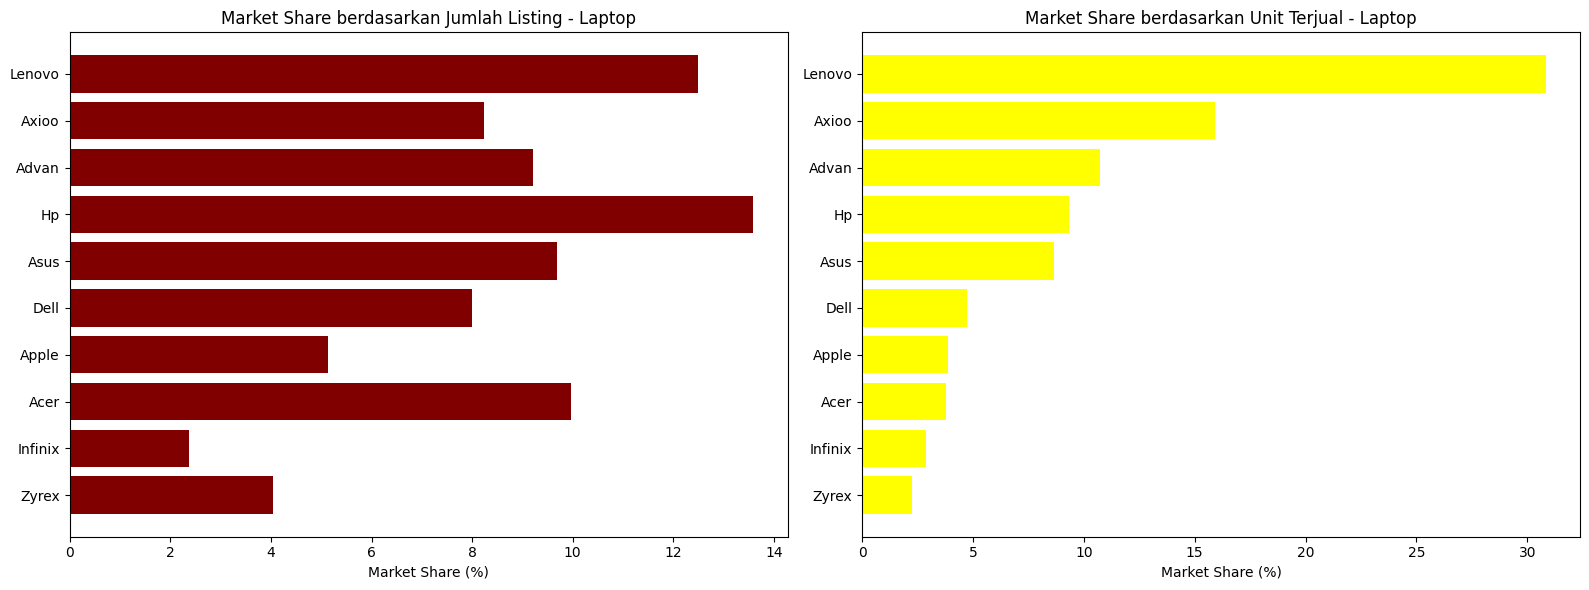

In [32]:
brand_summary_laptop = analisis_brand_dominance(df_laptop, 'Laptop')

# **Price Anomaly**

In [33]:
def analisis_price_anomaly(data, kategori_nama, min_listing=5):
    print(f"\n{'='*60}")
    print(f"PRICE ANOMALY DETECTION - KATEGORI {kategori_nama.upper()}")
    print(f"{'='*60}")

    hasil = []
    for brand, grup in data.groupby('brand'):
        if len(grup) < min_listing:
            continue
        Q1, Q3 = grup['harga'].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        batas_bawah, batas_atas = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        anomaly = grup[(grup['harga'] < batas_bawah) | (grup['harga'] > batas_atas)].copy()
        if len(anomaly) == 0:
            continue
        anomaly['tipe_anomaly'] = np.where(anomaly['harga'] > batas_atas, 'Overpriced', 'Underpriced/Suspicious')
        anomaly['batas_bawah'], anomaly['batas_atas'] = batas_bawah, batas_atas
        hasil.append(anomaly)

    df_anomaly = pd.concat(hasil) if hasil else pd.DataFrame()
    print(f"Total produk anomali: {len(df_anomaly)} dari {len(data)} listing ({len(df_anomaly)/len(data)*100:.2f}%)")
    if len(df_anomaly) > 0:
        print(df_anomaly['tipe_anomaly'].value_counts())
        cols = ['nama_produk', 'brand', 'harga', 'batas_bawah', 'batas_atas', 'tipe_anomaly', 'platform']
        print("\nContoh produk paling 'Overpriced' (top 10):")
        print(df_anomaly[cols].sort_values('harga', ascending=False).head(10).to_string(index=False))

    top_brand = data['brand'].value_counts().head(8).index
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=data[data['brand'].isin(top_brand)], x='brand', y='harga')
    plt.title(f'Distribusi Harga & Outlier per Brand - {kategori_nama}')
    plt.xticks(rotation=45)
    plt.ylabel('Harga (Rp)')
    plt.tight_layout()
    plt.show()
    return df_anomaly


PRICE ANOMALY DETECTION - KATEGORI LAPTOP
Total produk anomali: 727 dari 15096 listing (4.82%)
tipe_anomaly
Overpriced                726
Underpriced/Suspicious      1
Name: count, dtype: int64

Contoh produk paling 'Overpriced' (top 10):
                                                                                                                                                                                nama_produk     brand     harga  batas_bawah  batas_atas tipe_anomaly  platform
                                                                 MSI TITAN 18HX ULTRA 9 285HX RTX5090 24GB/ RAM 64GB SSD 6TB W11+OHS 18.0UHD+ MINILED 120HZ - NON BUNDLING, WINDOWS 11 HOME       Msi 199000000   -1091500.0  24010500.0   Overpriced Tokopedia
                                                                            SMARTINDO - Dell Pro Max 16 Premium (MA16250) Ultra 9 285H, 32GB, 1TB SSD, VGA RTX PRO 2000 8GB , WIN11PRO, 3YR      Dell 148000000   -5336000.0  17120000.0   Overpriced To

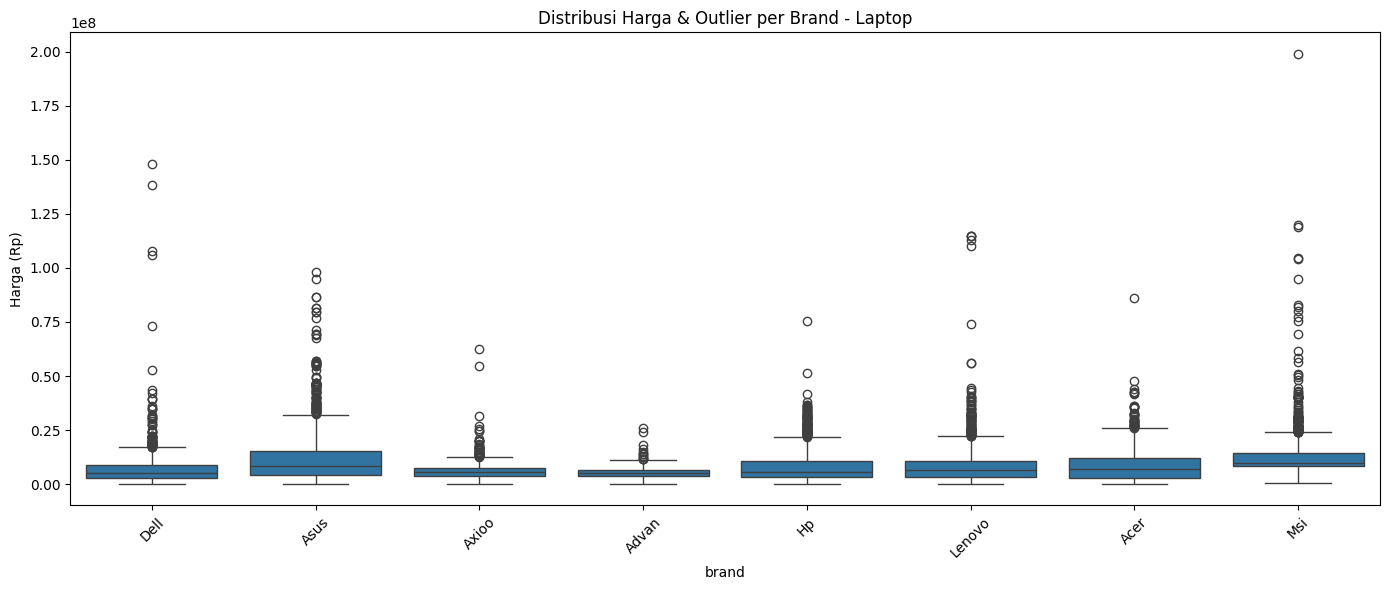

In [34]:
anomaly_laptop = analisis_price_anomaly(df_laptop, 'Laptop')

# **Analisis Depresiasi dan Likuiditas Pasar Bekas**

In [35]:
def analisis_depresiasi_likuiditas(data, kategori_nama, min_listing=5):
    print(f"\n{'='*60}")
    print(f"DEPRESIASI & LIKUIDITAS PASAR BEKAS - {kategori_nama.upper()}")
    print(f"{'='*60}")

    hasil = []
    for brand, grup in data.groupby('brand'):
        baru = grup[grup['kondisi'] == 'Baru']
        bekas = grup[grup['kondisi'] == 'Bekas']
        if len(baru) < min_listing or len(bekas) < min_listing:
            continue

        harga_baru, harga_bekas = baru['harga'].median(), bekas['harga'].median()
        depresiasi_pct = (1 - harga_bekas / harga_baru) * 100

        total_terjual_bekas = bekas['jumlah_terjual'].sum()
        avg_terjual_bekas = bekas['jumlah_terjual'].mean()
        pct_listing_terjual = (bekas['jumlah_terjual'] > 0).mean() * 100  # proksi likuiditas

        hasil.append({
            'brand': brand,
            'n_listing_baru': len(baru), 'n_listing_bekas': len(bekas),
            'median_harga_baru': harga_baru, 'median_harga_bekas': harga_bekas,
            'depresiasi(%)': round(depresiasi_pct, 2),
            'total_unit_terjual_bekas': total_terjual_bekas,
            'avg_unit_terjual_per_listing_bekas': round(avg_terjual_bekas, 2),
            'pct_listing_pernah_terjual(%)': round(pct_listing_terjual, 2)
        })

    df_hasil = pd.DataFrame(hasil).sort_values('depresiasi(%)', ascending=False)
    print(df_hasil.to_string(index=False))

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_hasil, x='depresiasi(%)', y='pct_listing_pernah_terjual(%)',
                     size='total_unit_terjual_bekas', sizes=(50, 800), legend=False)
    for _, row in df_hasil.iterrows():
        plt.text(row['depresiasi(%)'] + 0.3, row['pct_listing_pernah_terjual(%)'], row['brand'], fontsize=9)
    plt.axvline(df_hasil['depresiasi(%)'].median(), linestyle='--', color='red', alpha=0.6)
    plt.axhline(df_hasil['pct_listing_pernah_terjual(%)'].median(), linestyle='--', color='red', alpha=0.6)
    plt.title(f'Depresiasi vs Likuiditas Pasar Bekas per Brand - {kategori_nama}')
    plt.xlabel('Tingkat Depresiasi (%)')
    plt.ylabel('% Listing Bekas yang Pernah Terjual (Likuiditas)')
    plt.tight_layout()
    plt.show()
    return df_hasil


DEPRESIASI & LIKUIDITAS PASAR BEKAS - LAPTOP
    brand  n_listing_baru  n_listing_bekas  median_harga_baru  median_harga_bekas  depresiasi(%)  total_unit_terjual_bekas  avg_unit_terjual_per_listing_bekas  pct_listing_pernah_terjual(%)
     Asus            1031              431         11150000.0           2900000.0          73.99                     23549                               54.64                          72.85
     Acer            1212              291          8149500.0           2300000.0          71.78                      4276                               14.69                          71.48
   Lenovo            1189              696          8727000.0           3201666.5          63.31                    211260                              303.53                          91.81
    Apple             400              376         17123000.0           6500000.0          62.04                     11361                               30.22                          67.55
    

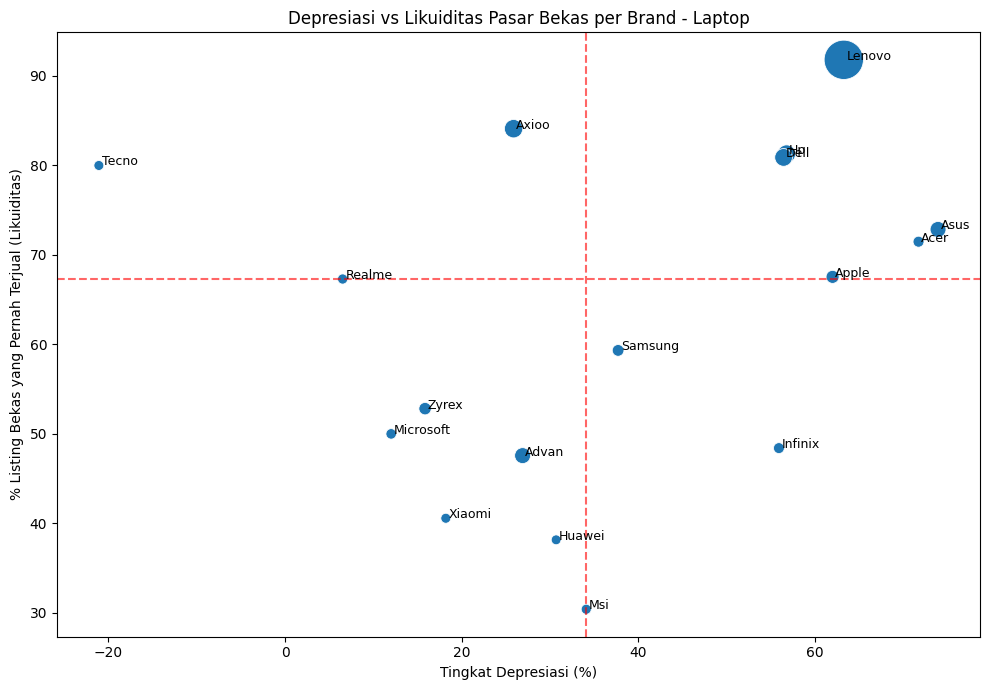

In [36]:
depresiasi_laptop = analisis_depresiasi_likuiditas(df_laptop, 'Laptop')

# **Herfindahl-Hirschman Index (HHI)**

In [37]:
def hitung_hhi(data, kategori_nama):
    print(f"\n{'='*60}")
    print(f"HERFINDAHL-HIRSCHMAN INDEX (HHI) - {kategori_nama.upper()}")
    print(f"{'='*60}")

    share_pct = data.groupby('brand')['jumlah_terjual'].sum()
    share_pct = share_pct / share_pct.sum() * 100
    hhi = (share_pct ** 2).sum()

    if hhi < 1500:
        interpretasi = "Pasar Kompetitif (tidak terkonsentrasi)"
    elif hhi < 2500:
        interpretasi = "Konsentrasi Moderat"
    else:
        interpretasi = "Pasar Terkonsentrasi Tinggi (oligopoli)"

    print(f"HHI (berbasis unit terjual): {hhi:.0f} -> {interpretasi}")
    return hhi

hhi_laptop = hitung_hhi(df_laptop, 'Laptop')


HERFINDAHL-HIRSCHMAN INDEX (HHI) - LAPTOP
HHI (berbasis unit terjual): 1555 -> Konsentrasi Moderat


# **Price Positioning Matrix**

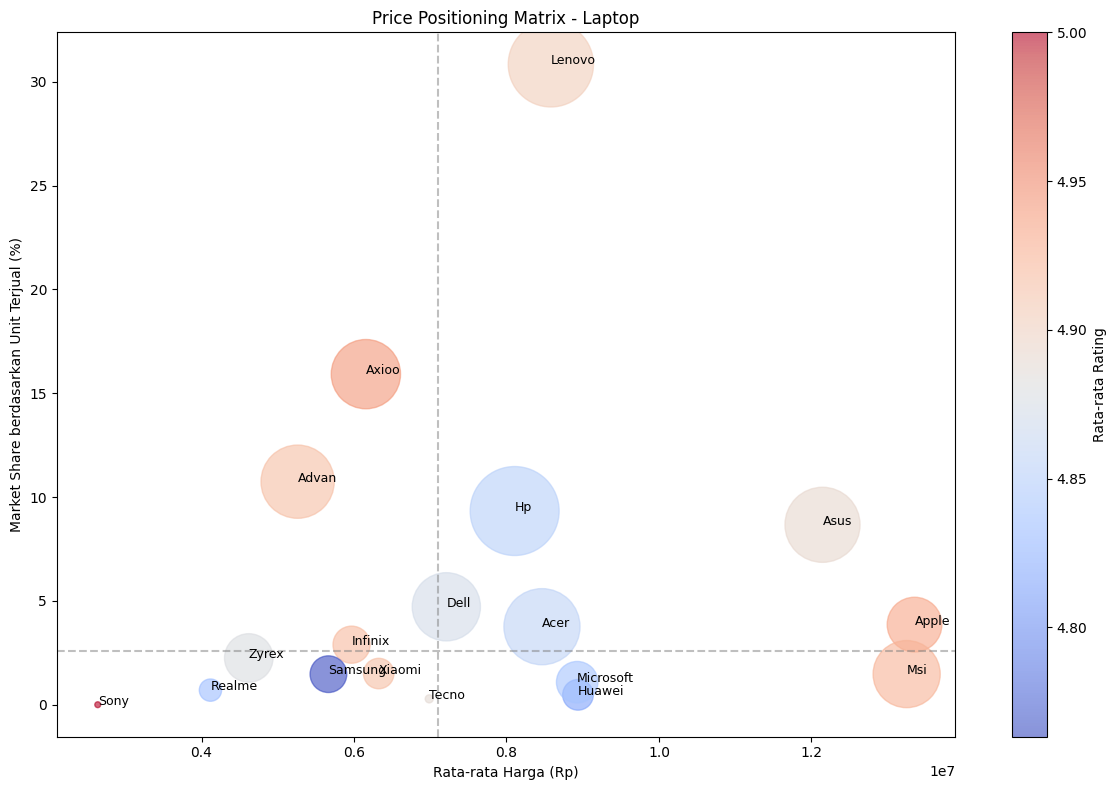

In [46]:
def price_positioning_matrix(data, kategori_nama):
    summary = data.groupby('brand').agg(
        avg_harga=('harga', 'mean'),
        total_terjual=('jumlah_terjual', 'sum'),
        n_listing=('nama_produk', 'count'),
        avg_rating=('rating', 'mean')
    ).reset_index()
    summary = summary[summary['n_listing'] >= 5]
    summary['market_share(%)'] = summary['total_terjual'] / summary['total_terjual'].sum() * 100

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(summary['avg_harga'], summary['market_share(%)'],
                           s=summary['n_listing'] * 2, alpha=0.6,
                           c=summary['avg_rating'], cmap='coolwarm')
    for _, row in summary.iterrows():
        plt.annotate(row['brand'], (row['avg_harga'], row['market_share(%)']), fontsize=9)
    plt.colorbar(scatter, label='Rata-rata Rating')
    plt.axvline(summary['avg_harga'].median(), linestyle='--', color='gray', alpha=0.5)
    plt.axhline(summary['market_share(%)'].median(), linestyle='--', color='gray', alpha=0.5)
    plt.xlabel('Rata-rata Harga (Rp)')
    plt.ylabel('Market Share berdasarkan Unit Terjual (%)')
    plt.title(f'Price Positioning Matrix - {kategori_nama}')
    plt.tight_layout()
    plt.show()
    return summary

positioning_laptop = price_positioning_matrix(df_laptop, 'Laptop')

# **Disparitas Harga Antar Platform**


DISPARITAS HARGA ANTAR PLATFORM - LAPTOP
 platform kondisi       mean     median  count
   Blibli    Baru 13844242.0 11377000.0   4451
   Shopee    Baru  6785430.0  6079000.0   2797
   Shopee   Bekas  5093965.0  4198000.0   2224
Tokopedia    Baru  8761929.0  6099000.0   2820
Tokopedia   Bekas  4108908.0  3500000.0   2804


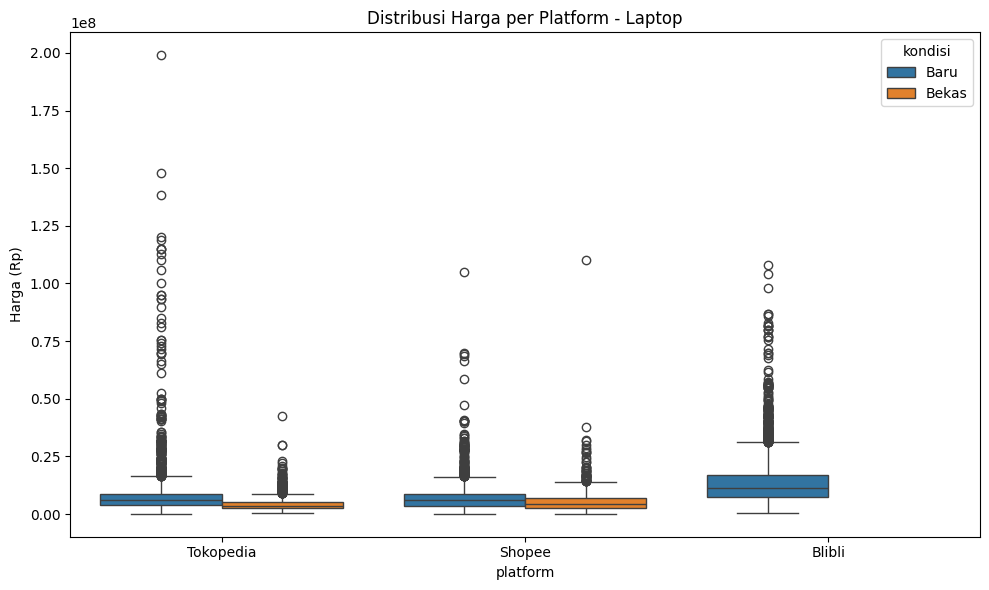

In [48]:
def analisis_disparitas_platform(data, kategori_nama):
    print(f"\n{'='*60}")
    print(f"DISPARITAS HARGA ANTAR PLATFORM - {kategori_nama.upper()}")
    print(f"{'='*60}")

    summary = data.groupby(['platform', 'kondisi'])['harga'].agg(['mean', 'median', 'count']).round(0).reset_index()
    print(summary.to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x='platform', y='harga', hue='kondisi')
    plt.title(f'Distribusi Harga per Platform - {kategori_nama}')
    plt.ylabel('Harga (Rp)')
    plt.tight_layout()
    plt.show()
    return summary
disparitas_laptop = analisis_disparitas_platform(df_laptop, 'Laptop')

# **Hidden Gems / Best Value Finder**

In [49]:
def cari_hidden_gems(data, kategori_nama, top_n=15):
    print(f"\n{'='*60}")
    print(f"HIDDEN GEMS (Best Value Products) - {kategori_nama.upper()}")
    print(f"{'='*60}")

    d = data[(data['rating'] > 0) & (data['jumlah_terjual'] > 0)].copy()
    d['z_harga_brand'] = d.groupby('brand')['harga'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
    d['skor_value'] = (d['rating'].rank(pct=True) * 0.4 +
                        d['jumlah_terjual'].rank(pct=True) * 0.4 +
                        (1 - d['z_harga_brand'].rank(pct=True)) * 0.2)

    top = d.sort_values('skor_value', ascending=False).head(top_n)
    cols = ['nama_produk', 'brand', 'harga', 'rating', 'jumlah_terjual', 'kondisi', 'platform', 'skor_value']
    print(top[cols].to_string(index=False))
    return top

gems_laptop = cari_hidden_gems(df_laptop, 'Laptop')


HIDDEN GEMS (Best Value Products) - LAPTOP
                                                                                                                                                                                                               nama_produk   brand   harga  rating  jumlah_terjual kondisi  platform  skor_value
                                                                                                                                             Infinix Xpad 20 LTE [8/256 GB] Garansi Resmi Infinix Indonesia - [8/256] Grey Infinix 2799000     5.0            2000    Baru Tokopedia    0.864463
【2025 baru】Laptop gaming murah Intel N95 15.6'' FHD IPS 16Gb 512Gb laptop Kunci sidik jari Garansi 1 Tahun Gratis Instalasi Windows 11 + office laptop gaming Generasi ke-11 Tipis Dan Portabel desain grafis Siswa laptop Infinix 1400000     5.0             413   Bekas    Shopee    0.839490
                                                                                         